In [ ]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

### GARCH

In [ ]:
# Example of downloading GARCH

from compare.baseline_garch import run_garch_baseline

garch_df_fast, garch_metrics_fast = run_garch_baseline(
    csv_path="dataset_finance_fred_full/eval_csv_with_context/gfc_2008_2010_with_context.csv",
    warmup=256,
    horizon=64,
    step=1,
    mean_type="AR",
    p=1,
    q=1,
    dist="normal",
    aggregate_mode="none",
    n_jobs=8,
    refit_every=5,
    show_progress=True,
    save_path="results/garch/gfc_h64s1.csv",
)


### Simple Baselines (ols, ridge, pls, pcr, rf)

In [ ]:
from compare.baselines import run_panel_baseline

df_rf, metrics_rf = run_panel_baseline(
    csv_path="dataset_finance_fred_full/eval_csv_with_context/inflation_2022_2023_with_context.csv",
    model_name="ols", # [ols, ridge, pls, pcr, rf]
    context_length=256,
    horizon=1,
    step=1,
    include_market=True,
    include_macro=True,
    n_jobs_outer=8, # let's speed this thing up =)
    save_path="results/baselines/ols/inf_h1.csv",
)
print(metrics_rf)

### Creating dataframes

We need a unique style of dataframes to easily compute metrics and plot graphics. Also, in case of horizon != window (step) we need to aggregate data properly.

`duplicate_mode` - parameter allows to define what type of aggreagtion is needed [mean, last, first]. In case, if data doen't need aggregation 'last' will be a proper choice.

In [ ]:
# Exanmple of creating proper dataframe from file with predictions

from compare.download_predictions import load_predictions

dl_df = load_predictions('results/mamba_fred_full/inf_p64.npz', duplicate_mode='last')
garch_df = load_predictions('results/garch/inf_h64s64.csv', duplicate_mode='last')

### Computing metrics

There is a lot of metrics, that can be commputed and looked at to undestand the quality of predictions. The once that are highlighted in the diploma are `huber`, `rmse`, `sign accuracy`.
All other metrics, their formulas and some explanation can be found in the file `compare/metrics_explanation.ipynb`.

In [5]:
# Example of computing metrics for several models' predictions

from compare.compute_metrics import compute_metrics_from_dataframe
from compare.download_predictions import load_predictions
import pandas as pd

crisis = 'cov'
paths = {'fred_full': 'mamba_fred_full', 'ols': 'baselines/ols', 'ridge': 'baselines/ridge', 'pcr': 'baselines/pcr', 'pls': 'baselines/pls', 'garch': 'garch'}
ending_dl = 'p1.npz'
ending_other = 'h1.csv'
results = dict()
for key, path in paths.items():
    if key == 'fred_full':
        ending = ending_dl
    else:
        ending = ending_other
    full_path = f'results/{path}/{crisis}_{ending}'
    df = load_predictions(full_path, duplicate_mode='last')
    metrics = compute_metrics_from_dataframe(df)
    results[key] = metrics

df_results = pd.DataFrame.from_dict(results, orient='index')
df_results

,n,mse,rmse,mae,huber,sign_accuracy,negative_day_sign_accuracy,mase,tail_rmse_10,tail_mae_10,downside_hit_rate_10,downside_precision_10,downside_f1_10,tail_rmse_5,tail_mae_5,downside_hit_rate_5,downside_precision_5,downside_f1_5
fred_full,245430,0.000767,0.027687,0.017387,0.000383,0.524284,0.000000,0.882078,0.059292,0.048759,0.084260,0.070885,0.076996,0.077963,0.066862,0.035610,0.033336,0.034435
ols,244760,0.001262,0.035524,0.022893,0.000631,0.512228,0.413230,1.163964,0.066273,0.052836,0.192474,0.192474,0.192474,0.082724,0.069428,0.144305,0.144305,0.144305
ridge,244760,0.001261,0.035505,0.022880,0.000630,0.512261,0.413247,1.163282,0.066242,0.052819,0.192883,0.192883,0.192883,0.082692,0.069408,0.144386,0.144386,0.144386
pcr,244760,0.000829,0.028790,0.018314,0.000414,0.512445,0.469730,0.931173,0.055073,0.045367,0.236150,0.236150,0.236150,0.070924,0.060308,0.237621,0.237621,0.237621
pls,244760,0.000935,0.030573,0.019606,0.000467,0.504470,0.460271,0.996817,0.055058,0.045053,0.254658,0.254658,0.254658,0.069599,0.058507,0.257395,0.257395,0.257395
garch,245239,0.000764,0.027648,0.017364,0.000382,0.518449,0.176030,0.883065,0.059884,0.049506,0.157438,0.157431,0.157434,0.078505,0.067528,0.125183,0.125153,0.125168


### Plotting 

In [15]:
ticker = 'BAC'
model_1_name = 'Proposed Model'
model_2_name = 'GARCH(1,1)'
true_values = 'dataset_finance_fred_full/eval_csv_with_context/gfc_2008_2010_with_context.csv'
model_1_results = 'results/mamba_fred_full/gfc_p64.npz'
model_2_results = 'results/garch/gfc_h64s64.csv'

start_date = '2008-01-02'
end_date = '2010-06-30'
q = 0.05
aggregated_mode = 'last'

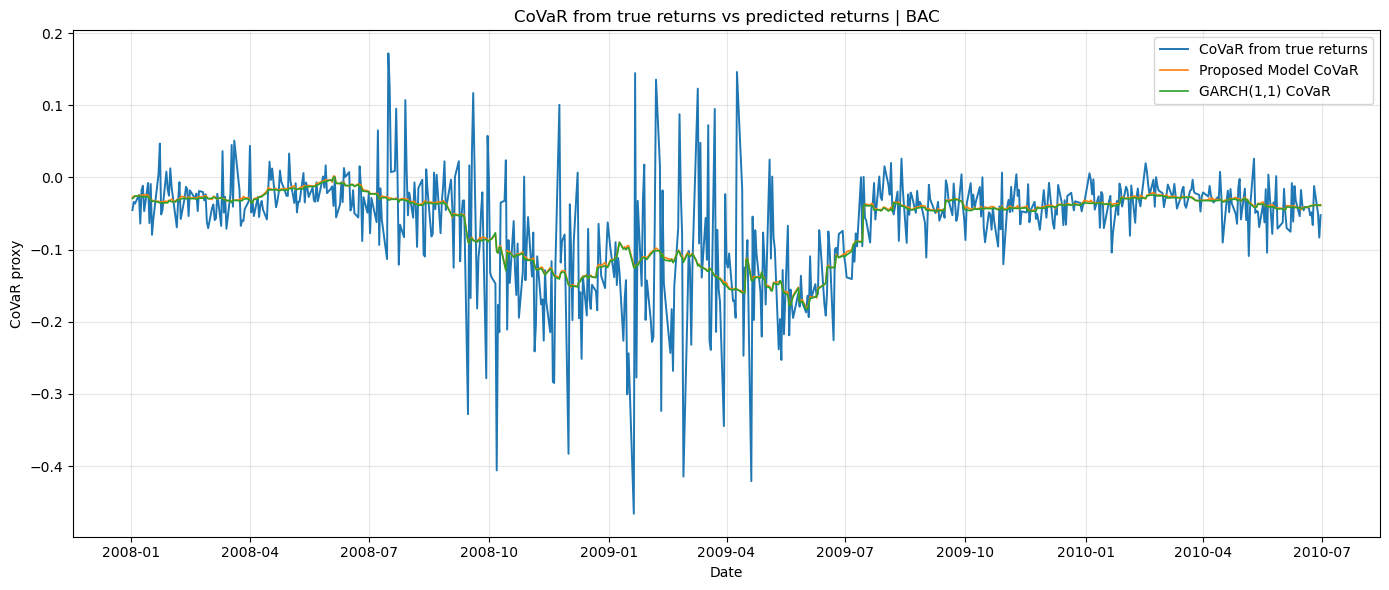

In [17]:
from compare.plot_graphics import plot_covar_true_vs_predicted
from compare.download_predictions import load_predictions

df1 = load_predictions(model_1_results , duplicate_mode=aggregated_mode)
df2 = load_predictions(model_2_results, duplicate_mode=aggregated_mode)


plot_covar_true_vs_predicted(
    df_1=df1,
    df_2=df2,
    panel=true_values,
    model_1_name=model_1_name,
    model_2_name=model_2_name,
    ticker=ticker,
    start_date=start_date,
    end_date=end_date,
    aggregate_mode=aggregated_mode ,
    q=q,
)

In case of drawing some risk metrics, like VaR, CoVaR and $\Delta$CoVar first some computations must happen. Below some of the examples.

In [ ]:
from compare.quantile_regression_covar import compute_quantile_regression_covar, evaluate_covar_tracking


qr_1_pred = compute_quantile_regression_covar(
    pred_df=df1,
    panel=true_values,
    ticker=ticker,
    q=q,
    institution_mode="pred",
    warmup=60,
    step=1,
)

qr_2_pred = compute_quantile_regression_covar(
    pred_df=df2,
    panel=true_values,
    ticker=ticker,
    q=q,
    institution_mode="pred",
    warmup=60,
    step=1,
)

qr_ref = compute_quantile_regression_covar(
    pred_df=df1,
    panel=true_values,
    ticker=ticker,
    q=q,
    institution_mode="true",
    warmup=60,
    step=1,
)

Now, it is possible to plot only one or both dataframes risk metrics. 

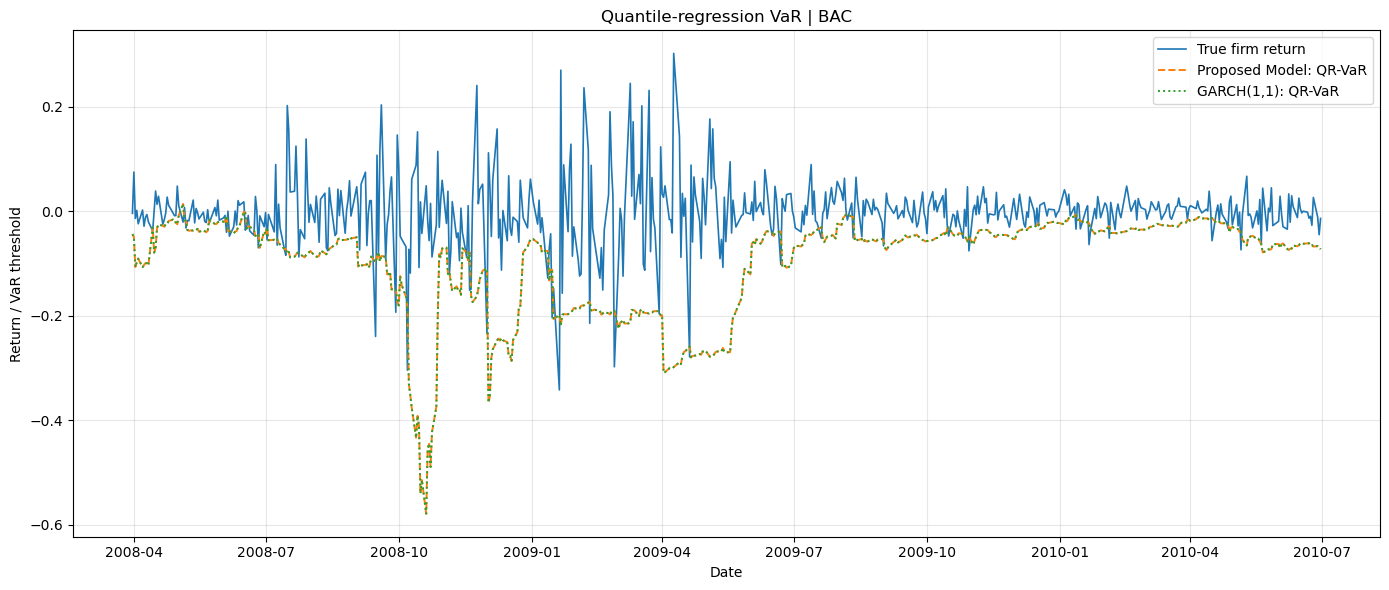

In [63]:
from compare.quantile_regression_covar import plot_qr_var

plot_qr_var(
    qr_df_1=qr_1_pred,
    qr_df_2=qr_2_pred,
    model_1_name=model_1_name,
    model_2_name=model_2_name,
    ticker=ticker,
    start_date=start_date,
    end_date=end_date
)

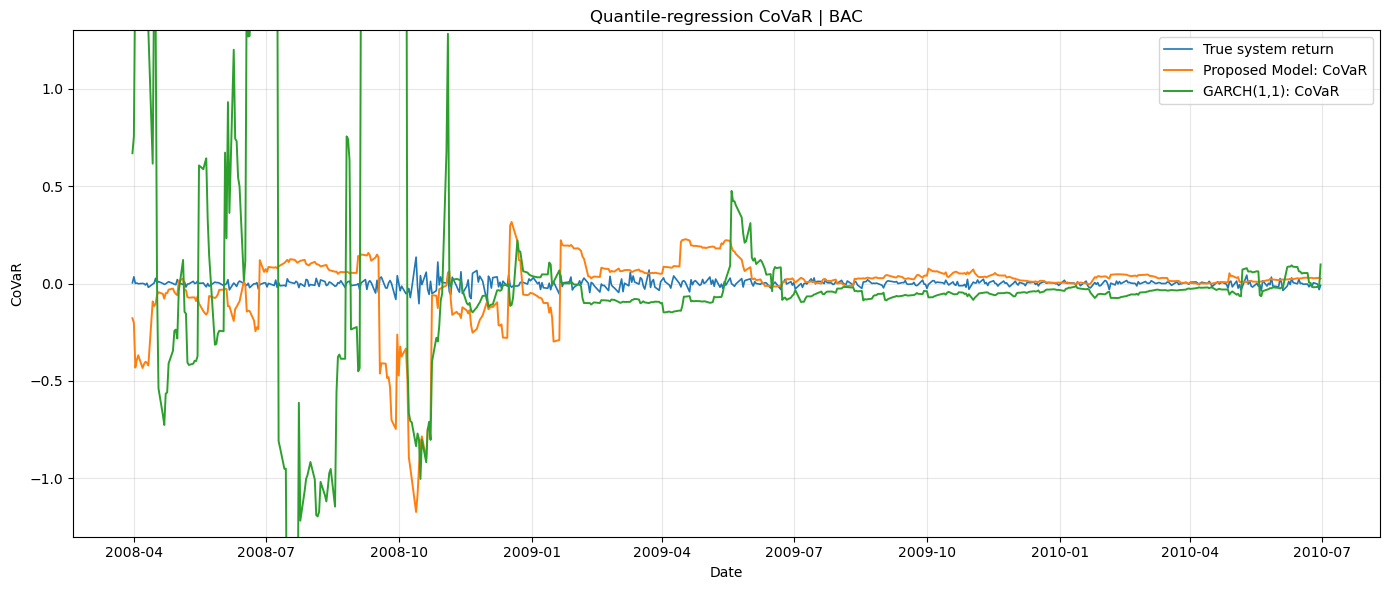

In [19]:
from compare.quantile_regression_covar import plot_qr_covar, add_covar_uncertainty_bands


qr_1_pred_covar = add_covar_uncertainty_bands(
    qr_1_pred,
    window=60,
    min_periods=60,
    alpha=0.05,
)

qr_2_pred_covar = add_covar_uncertainty_bands(
    qr_2_pred,
    window=60,
    min_periods=60,
    alpha=0.05,
)

plot_qr_covar(
    qr_df_1=qr_1_pred_covar,
    qr_df_2=qr_2_pred_covar,
    model_1_name=model_1_name,
    model_2_name=model_2_name,
    ticker=ticker,
    start_date=start_date,
    end_date=end_date,
    # show_confidence_band=True,
)

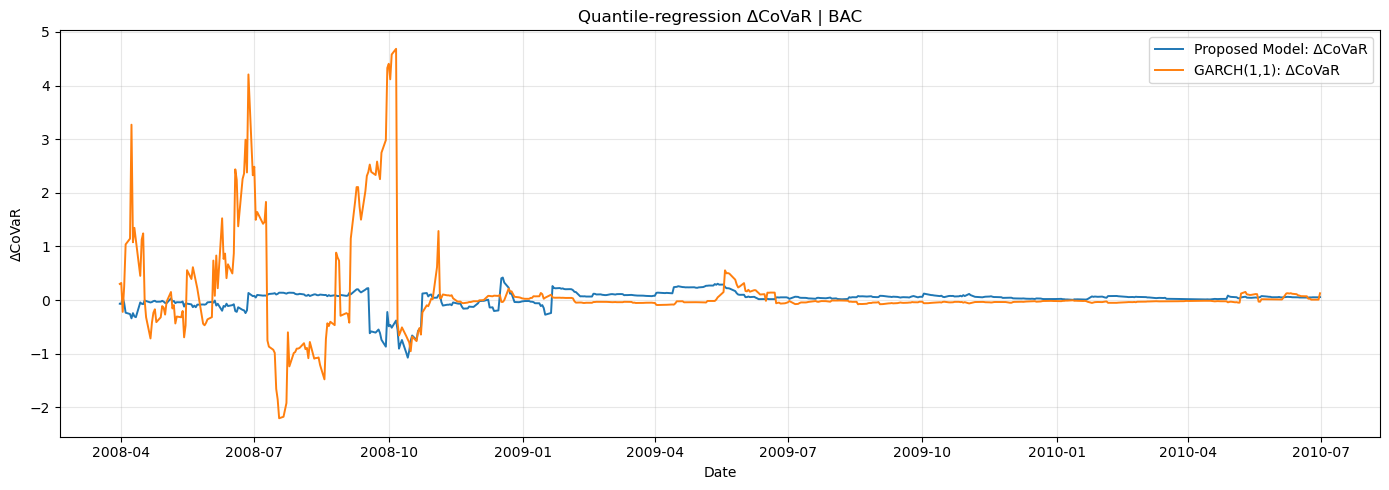

In [18]:
from compare.quantile_regression_covar import plot_qr_delta_covar, add_delta_covar_uncertainty_bands

qr_1_pred_delta = add_delta_covar_uncertainty_bands(
    qr_df=qr_1_pred,
    reference_qr_df=qr_ref,
    window=60,
    min_periods=60,
    alpha=0.05,
    ticker=ticker,
)

qr_2_pred_delta = add_delta_covar_uncertainty_bands(
    qr_df=qr_2_pred,
    reference_qr_df=qr_ref,
    window=60,
    min_periods=60,
    alpha=0.05,
    ticker=ticker,
)

plot_qr_delta_covar(
    qr_df_1=qr_1_pred_delta,
    qr_df_2=qr_2_pred_delta,
    model_1_name=model_1_name,
    model_2_name=model_2_name,
    ticker=ticker,
    start_date=start_date,
    end_date=end_date,
    # show_confidence_band=True
)

Some related metrics to risk metrics can be also computed

In [ ]:
metrics_dl = evaluate_covar_tracking(
    predicted_qr_df=qr_1_pred,
    reference_qr_df=qr_ref,
    ticker=ticker,
    start_date=start_date,
    end_date=end_date
)
print(metrics_dl)

metrics_garch = evaluate_covar_tracking(
    predicted_qr_df=qr_2_pred,
    reference_qr_df=qr_ref,
    ticker=ticker,
    start_date=start_date,
    end_date=end_date
)
print(metrics_garch)